In [4]:
from __future__ import annotations

import math
from dataclasses import asdict, dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Spindelkeuze

GLOBALE AS-GEOMETRIE

Spindelselectie: HIWIN R40-20T2-DDB-2350-2478-0.023
HIWIN sizing ID: HGLMQGADAM  (datum 10-03-2026)

Dimensies:
Nominale diameter    : 40 mm
Spoed                : 20 mm
Vrije lengte         : 2 350 mm  (= HIWIN "Free length")
Schachtlengte totaal : 2 478 mm
Eindbewerking (vast) : 128 mm  (= 2478 − 2350)

Capaciteit (uit HIWIN design data sheet):
1. C_dyn  : 24 300 N
2. C0     : 36 400 N
3. n_k    : 1 221 rpm   (kritisch toerental, HIWIN catalogus)
4. n_max  :   977 rpm   (toelaatbaar max. toerental, HIWIN catalogus)
5. Fk,Euler : 61 552 N  (volledige Euler-kniклast, HIWIN)
6. Fkzul  : 30 776 N   (toelaatbaar, incl. veiligheidsfactor 2 van HIWIN)
7. s0     : 14.47       (statische veiligheid bij Fmax = 1 433 N)
8. Fbm    :  2 508 N    (gemiddelde bedrijfsbelasting, HIWIN cyclus)
9. Cd/Fbm :  9.69
10. L10    :  8 000 km   (levensduur, HIWIN bedrijfsprofiel)

HIWIN-bedrijfsprofiel (HGLMQGADAM) vs. ons ontwerpmodel:
- HIWIN: v=0.30 m/s, a=0.081 m/s², tpos=11 s, 30 cycli/uur
- Ons  : v=0.28 m/s, a=0.80  m/s², voor verificatie statische sterkte

In [5]:

M1_SLAG_M            = 2.200   # m   werkslag
M1_SCHACHT_TOTAAL_M  = 2.478   # m   totale schachtlengte
M1_EINDBEWERKING_M   = 0.128   # m   2478 − 2350 mm
M1_VRIJE_LENGTE_M    = round(M1_SCHACHT_TOTAAL_M - M1_EINDBEWERKING_M, 4)  # 2.350 m


# ─────────────────────────────────────────────────────────────────────────────
# OPERATIONEEL PROFIEL (voor levensduurberekening)
# ─────────────────────────────────────────────────────────────────────────────
CYCLI_PER_UUR       = 30
BEDRIJFSUREN_PER_DAG = 8
WERKDAGEN_PER_JAAR  = 220
VEREISTE_LEVENSDUUR_JAAR = 10


# ─────────────────────────────────────────────────────────────────────────────
# HULPFUNCTIES
# ─────────────────────────────────────────────────────────────────────────────
def veilige_del(a: float, b: float, fallback: float = float("nan")) -> float:
    return fallback if abs(b) < 1e-16 else a / b


def rpm_uit_snelheid_en_spoed(snelheid_m_s: float, spoed_m: float) -> float:
    return veilige_del(60.0 * snelheid_m_s, spoed_m, float("nan")) if spoed_m > 0.0 else float("nan")


def koppel_uit_axiale_kracht(kracht_N: float, spoed_m: float, rendement: float) -> float:
    if spoed_m <= 0.0 or rendement <= 0.0:
        return float("nan")
    return kracht_N * spoed_m / (2.0 * math.pi * rendement)


def vermogen_uit_kracht_en_snelheid(kracht_N: float, snelheid_m_s: float, rendement: float) -> float:
    if rendement <= 0.0:
        return float("nan")
    return kracht_N * snelheid_m_s / rendement


def oppervlaktemoment_cirkel(diameter_m: float) -> float:
    return math.pi * diameter_m**4 / 64.0


def derdegraads_equivalente_kracht(krachten_N: List[float], tijden_s: List[float]) -> float:
    """
    Equivalente kracht volgens kubiekswortelgemiddelde (ISO-methode voor
    spindels en lagers met p=3 exponent).
    F_eq = [ Σ(Fi³ × ti) / Σ(ti) ]^(1/3)
    """
    F = np.asarray(krachten_N, dtype=float)
    t = np.asarray(tijden_s, dtype=float)
    if len(F) != len(t) or np.any(t < 0.0) or np.sum(t) <= 0.0:
        return float("nan")
    return float((np.sum(F**3 * t) / np.sum(t)) ** (1.0 / 3.0))


def toon_dataframe(naam: str, df: pd.DataFrame, max_rijen: int = 20) -> None:
    print(f"\n=== {naam.upper()} ===")
    if len(df) > max_rijen:
        print(df.head(max_rijen).to_string(index=False))
        print(f"... ({len(df)} rijen in totaal)")
    else:
        print(df.to_string(index=False))

FALLBACK

In [6]:
try:
    resultaten_interface
except NameError:
    resultaten_interface = {
        "export_voor_volgende_modules": {
            "massa_effectief_op_slede_kg":    120.2 , # Tom v19,
            "massa_te_versnellen_door_m1_kg": 120.2 , # Tom v19,
            "Fz_max_N":  1291.287580523783,
            "Fx_max_N":   105.30377822832081,
            "Fy_max_N":     0.0,
            "Mx_max_Nm":   40.95 , # Tom v19.044384736161795,
            "My_max_Nm":  494.7836254470391,
            "Mz_max_Nm":    1.3899604176254257,
        }
    }

LEVENSDUUR DOELSTELLING

In [7]:
def bereken_doel_levensduur_km(
    cycli_per_uur: int,
    bedrijfsuren_per_dag: int,
    werkdagen_per_jaar: int,
    slag_m: float,
    vereiste_jaren: int,
    veiligheidsfactor_leven: float = 2.5,
) -> Tuple[float, float]:
    """
    Berekent de vereiste spindel-levensduur in km op basis van het
    operationele profiel en de gevraagde diensttijd.

    Parameters
    ----------
    veiligheidsfactor_leven : float
        Marge bovenop de kalendereis (default 2.5 voor L10-leven).
        Achtergrond: L10 is het moment waarop 10% van de spindels faalt;
        voor een systeem met 1 spindel is extra marge gewenst.

    Returns
    -------
    km_per_jaar       : float   km per bedrijfsjaar
    doel_km           : float   vereist L10-leven [km]
    """
    km_per_jaar = cycli_per_uur * bedrijfsuren_per_dag * werkdagen_per_jaar * 2 * slag_m / 1000.0
    doel_km = vereiste_jaren * km_per_jaar * veiligheidsfactor_leven
    return km_per_jaar, doel_km


_km_per_jaar, _doel_km = bereken_doel_levensduur_km(
    CYCLI_PER_UUR, BEDRIJFSUREN_PER_DAG, WERKDAGEN_PER_JAAR,
    M1_SLAG_M, VEREISTE_LEVENSDUUR_JAAR,
)
print(
    f"Operationeel: {_km_per_jaar:.1f} km/jaar  →  "
    f"doel L10 = {_doel_km:.0f} km  "
    f"(= {VEREISTE_LEVENSDUUR_JAAR} jaar × factor 2.5)"
)
print(f"HIWIN L10 = 8000 km  →  marge t.o.v. doel = {8000/_doel_km:.1f}×")

Operationeel: 232.3 km/jaar  →  doel L10 = 5808 km  (= 10 jaar × factor 2.5)
HIWIN L10 = 8000 km  →  marge t.o.v. doel = 1.4×


DATACLASSES

In [8]:
@dataclass(frozen=True)
class BewegingsProfielSpindel:
    """
    Worst-case bewegingsprofiel voor sterkte- en toerental-verificatie.
    Noot: HIWIN sizing tool gebruikt a=0.081 m/s² voor L10-berekening;
    dit model hanteert a=0.80 m/s² voor conservatieve lastbepaling.
    """
    slag_m:      float = M1_SLAG_M   # 2.200 m
    v_max_m_s:   float = 0.28
    a_max_m_s2:  float = 0.80
    stilstand_s: float = 0.0


@dataclass(frozen=True)
class ConfiguratieSpindel:
    """
    HIWIN R40-20T2-DDB — alle cataloguswaarden direct overgenomen uit
    HIWIN design data sheet (Sizing ID HGLMQGADAM, 10-03-2026).

    Lengte-afhankelijke waarden zijn DIRECT uit HIWIN-tool; géén handmatige
    schaling nodig. Lengte-onafhankelijke waarden (Cdyn, C0, s0) idem.
    """
    naam_spindel: str = "HIWIN R40-20T2-DDB"

    # ── Geometrie ───────────────────────────────────────────────────────────
    nominale_diameter_spindel_m:  float = 0.040
    kerndiameter_spindel_m:       float = 0.03573   # terugberekend uit Fk_Euler
    spoed_spindel_m:              float = 0.020
    rendement_spindel:            float = 0.92       # typisch voor HIWIN kogelloopspindel
    vrije_lengte_spindel_m:       float = M1_VRIJE_LENGTE_M   # 2.350 m
    totale_lengte_spindel_m:      float = M1_SCHACHT_TOTAAL_M # 2.478 m

    # ── Toerental (HIWIN design data sheet) ─────────────────────────────────
    n_k_catalogus_rpm:    float = 1221.0   # kritisch toerental [rpm]
    n_max_catalogus_rpm:  float =  977.0   # max. toelaatbaar toerental [rpm]

    # ── Knikveiligheid (HIWIN design data sheet) ─────────────────────────────
    #    Fk_Euler = 61 552 N,  Fkzul = 30 776 N (veiligheidsfactor 2 in HIWIN)
    F_k_toelaatbaar_N:    float = 30_776.0   # N — Fkzul uit HIWIN

    # ── Statische veiligheid (HIWIN design data sheet) ───────────────────────
    #    s0 = C0 / Fmax = 36 400 / 1 433 = 25.4 (HIWIN Fmax bij eigen cyclus)
    #    Bij ons Fmax (= F_piek) is s0 berekend als 36 400 / F_piek.
    s0_berekend_hiwin:    float = 25.4    # HIWIN waarde (eigen cyclus)
    s0_min:               float = 3.0

    # ── Dynamische capaciteit (HIWIN design data sheet) ──────────────────────
    #    Cdyn / Fbm = 24 300 / 2 508 = 9.69  ← HIWIN design data sheet
    C_dyn_N:                         float = 24_300.0
    C0_N:                            float = 36_400.0
    verhouding_Cd_over_Fbm_berekend: float =  9.69
    verhouding_Cd_over_Fbm_min:      float =  5.0
    Fbm_catalogus_N:                 float =  2_508.0   # HIWIN gemiddelde last

    # ── Levensduur (HIWIN design data sheet) ─────────────────────────────────
    L10_hiwin_km:                    float =  8_000.0   # km — HIWIN uitkomst
    doel_levensduur_spindel_km:      float = _doel_km   # afgeleid uit operationeel profiel

    # ── Oplegging en materiaal ─────────────────────────────────────────────
    oplegging_spindel: str  = "vast-zwevend"
    E_spindel_Pa:      float = 210e9

    # ── Ontwerpfactoren ────────────────────────────────────────────────────
    factor_fw:                    float = 1.3
    minimum_knikveiligheid:       float = 3.0
    limiet_benutting_toerental:   float = 0.90   # n_bedrijf ≤ 0.90 × n_max
    limiet_benutting_kritisch:    float = 0.80   # n_bedrijf ≤ 0.80 × n_k
    schokfactor:                  float = 1.25
    verhouding_wrijving:          float = 0.05

    # ── Axiale statische last (verticale as) ─────────────────────────────────
    #    De M1-as is verticaal: extra_axiale_kracht = gewicht van de slede.
    #    Waarde wordt geladen vanuit resultaten_interface["Fz_max_N"].
    extra_axiale_kracht_N: float = 1179.3  # Tom v19   # N (fallback)

BEWEGINGSPROFIEL

In [9]:
def profiel_tijden(slag_m: float, v_max_m_s: float, a_max_m_s2: float) -> Dict[str, float]:
    """
    Trapezoïdaal of driehoekig snelheidsprofiel.
    Geeft tijden en piksnelheid voor het gegeven slag/snelheid/versnelling.
    """
    if slag_m <= 0.0 or v_max_m_s <= 0.0 or a_max_m_s2 <= 0.0:
        return {
            "profiel": "ongeldig", "t_versnellen_s": 0.0,
            "t_constante_snelheid_s": 0.0, "t_vertragen_s": 0.0,
            "v_piek_m_s": 0.0, "t_totaal_s": 0.0,
        }
    t_acc  = v_max_m_s / a_max_m_s2
    s_acc  = 0.5 * a_max_m_s2 * t_acc**2
    if 2.0 * s_acc >= slag_m:
        t_acc  = math.sqrt(slag_m / a_max_m_s2)
        v_piek = a_max_m_s2 * t_acc
        return {
            "profiel": "driehoekig", "t_versnellen_s": t_acc,
            "t_constante_snelheid_s": 0.0, "t_vertragen_s": t_acc,
            "v_piek_m_s": v_piek, "t_totaal_s": 2.0 * t_acc,
        }
    t_cte = (slag_m - 2.0 * s_acc) / v_max_m_s
    return {
        "profiel": "trapezium", "t_versnellen_s": t_acc,
        "t_constante_snelheid_s": t_cte, "t_vertragen_s": t_acc,
        "v_piek_m_s": v_max_m_s, "t_totaal_s": 2.0 * t_acc + t_cte,
    }

BELASTINGSCYCLUS

In [10]:
def belastingcyclus_spindel(
    massa_te_versnellen_kg: float,
    extra_axiale_N: float,
    cfg_beweging: BewegingsProfielSpindel,
    cfg_spindel: ConfiguratieSpindel,
) -> Dict[str, float]:
    """
    Berekent axiale krachten per bewegingssegment en de equivalente kracht F_eq.

    Verticale as: extra_axiale_N = gewicht (statisch draagvermogen).
      Versnellen omhoog : F = Fz + m×a  (worst case — beide termen optellen)
      Constante snelheid: F = Fz         (alleen gewicht)
      Vertragen omhoog  : F = Fz − m×a  (gunstig, maar we hanteren Fz + m×a
                                          als conservatief worst-case)
    Schokfactor fw en wrijvingsfactor (1+f) worden globaal toegepast.
    """
    profiel = profiel_tijden(cfg_beweging.slag_m, cfg_beweging.v_max_m_s,
                             cfg_beweging.a_max_m_s2)
    fw  = cfg_spindel.schokfactor
    eta = 1.0 + cfg_spindel.verhouding_wrijving

    F_acc_basis = extra_axiale_N + massa_te_versnellen_kg * cfg_beweging.a_max_m_s2
    F_cte_basis = extra_axiale_N
    F_dec_basis = extra_axiale_N + massa_te_versnellen_kg * cfg_beweging.a_max_m_s2

    F_acc = fw * F_acc_basis * eta
    F_cte = fw * F_cte_basis * eta
    F_dec = fw * F_dec_basis * eta

    F_eq = derdegraads_equivalente_kracht(
        [F_acc, F_cte, F_dec],
        [profiel["t_versnellen_s"], profiel["t_constante_snelheid_s"],
         profiel["t_vertragen_s"]],
    )
    return {
        **profiel,
        "F_versnellen_basis_N": F_acc_basis,
        "F_constante_basis_N":  F_cte_basis,
        "F_vertragen_basis_N":  F_dec_basis,
        "F_versnellen_N":       F_acc,
        "F_constante_N":        F_cte,
        "F_vertragen_N":        F_dec,
        "F_equivalent_N":       F_eq,
    }

KNIK EN KRITISCH TOERENTAL

In [11]:
def kniklast_euler(E_Pa, kern_diameter_m, vrije_lengte_m, factor_K):
    """Euler kniклast voor een cilindrische staaf. Ref: Timoshenko, Theory of
    Elastic Stability, 2nd ed., §2.3."""
    if min(E_Pa, kern_diameter_m, vrije_lengte_m, factor_K) <= 0.0:
        return float("nan")
    I = oppervlaktemoment_cirkel(kern_diameter_m)
    return math.pi**2 * E_Pa * I / (factor_K * vrije_lengte_m)**2


def vereiste_kern_diameter_uit_knik(F_ontwerp_N, E_Pa, vrije_lengte_m, factor_K):
    """Minimale kerndiameter o.b.v. Euler-knikcriterium met veiligheidsfactor."""
    if min(F_ontwerp_N, E_Pa, vrije_lengte_m, factor_K) <= 0.0:
        return float("nan")
    I_vereist = F_ontwerp_N * (factor_K * vrije_lengte_m)**2 / (math.pi**2 * E_Pa)
    return ((64.0 * I_vereist) / math.pi) ** 0.25


def factor_K_uit_oplegging(oplegging: str) -> float:
    """Euler insluitfactor K voor diverse opleggingen. Ref: HIWIN catalog §4.3."""
    return {
        "vast-vast": 0.5, "vast-ondersteund": 0.7, "vast-zwevend": 0.7,
        "ondersteund-ondersteund": 1.0, "vast-vrij": 2.0,
    }.get(oplegging, 0.7)


def kritische_toerental_schatting_rpm(kern_diameter_m, vrije_lengte_m, oplegging):
    """
    Empirische schattingsformule HIWIN: n_k = f × 4.76×10⁶ × d[mm] / L[mm]².
    Opleggingsfactor f: vast-zwevend = 17.7. Ref: HIWIN Ball Screw Selection §2.
    Noot: waarde wijkt af van n_k_catalogus; cataloguswaarde is maatgevend.
    """
    factoren = {
        "vast-vast": 25.5, "vast-ondersteund": 17.7, "vast-vrij": 3.9,
        "ondersteund-ondersteund": 11.5, "vast-zwevend": 17.7,
    }
    d_mm = 1000.0 * kern_diameter_m
    L_mm = 1000.0 * vrije_lengte_m
    if d_mm <= 0.0 or L_mm <= 0.0:
        return float("nan")
    return factoren.get(oplegging, 17.7) * 4.76e6 * d_mm / (L_mm**2)

DIMENSIONERING

In [12]:
def dimensioneer_spindel_algemeen(
    cfg_beweging: BewegingsProfielSpindel,
    cfg_spindel: ConfiguratieSpindel,
    cyclus: Dict[str, float],
) -> Dict[str, float]:
    n_bedrijf = rpm_uit_snelheid_en_spoed(cyclus["v_piek_m_s"], cfg_spindel.spoed_spindel_m)
    factor_K  = factor_K_uit_oplegging(cfg_spindel.oplegging_spindel)

    # Minimale spoed zodat n_bedrijf ≤ limiet × n_max
    lead_min = veilige_del(
        60.0 * cyclus["v_piek_m_s"],
        cfg_spindel.limiet_benutting_toerental * cfg_spindel.n_max_catalogus_rpm,
    )

    # Vereiste Cdyn op basis van gewenste levensduur
    omwentelingen_doel = veilige_del(
        cfg_spindel.doel_levensduur_spindel_km * 1000.0,
        cfg_spindel.spoed_spindel_m,
    )
    C_vereist_levensduur = (
        cyclus["F_equivalent_N"] * cfg_spindel.factor_fw
        * (omwentelingen_doel / 1e6) ** (1.0 / 3.0)
    )
    C_vereist_verhouding = cfg_spindel.verhouding_Cd_over_Fbm_min * max(cyclus["F_equivalent_N"], 1.0)

    # Minimale kerndiameter voor knikcriterium
    d_kern_vereist_knik = vereiste_kern_diameter_uit_knik(
        cyclus["F_versnellen_N"] * cfg_spindel.minimum_knikveiligheid,
        cfg_spindel.E_spindel_Pa,
        cfg_spindel.vrije_lengte_spindel_m,
        factor_K,
    )

    return {
        "lead_min_m": lead_min,
        "n_bedrijf_rpm": n_bedrijf,
        "F_piek_N": cyclus["F_versnellen_N"],
        "F_eq_N":   cyclus["F_equivalent_N"],
        "C_vereist_levensduur_N": C_vereist_levensduur,
        "C_vereist_verhouding_N": C_vereist_verhouding,
        "d_kern_vereist_knik_m": d_kern_vereist_knik,
        "factor_K_knik": factor_K,
    }

VERIFICATIE

In [13]:
def verifieer_spindel(
    cfg_spindel: ConfiguratieSpindel,
    cyclus: Dict[str, float],
    eisen: Dict[str, float],
) -> Tuple[Dict[str, float], pd.DataFrame]:
    n_bedrijf = rpm_uit_snelheid_en_spoed(cyclus["v_piek_m_s"], cfg_spindel.spoed_spindel_m)

    benutting_nmax  = veilige_del(n_bedrijf, cfg_spindel.n_max_catalogus_rpm)
    benutting_nk    = veilige_del(n_bedrijf, cfg_spindel.n_k_catalogus_rpm)
    n_k_schatting   = kritische_toerental_schatting_rpm(
        cfg_spindel.kerndiameter_spindel_m,
        cfg_spindel.vrije_lengte_spindel_m,
        cfg_spindel.oplegging_spindel,
    )

    Pcr = kniklast_euler(
        cfg_spindel.E_spindel_Pa, cfg_spindel.kerndiameter_spindel_m,
        cfg_spindel.vrije_lengte_spindel_m, eisen["factor_K_knik"],
    )
    benutting_knik = veilige_del(cyclus["F_versnellen_N"], Pcr)

    # Statische veiligheid o.b.v. eigen F_piek
    s0_berekend = veilige_del(cfg_spindel.C0_N, cyclus["F_versnellen_N"])

    koppel_piek    = koppel_uit_axiale_kracht(
        cyclus["F_versnellen_N"], cfg_spindel.spoed_spindel_m, cfg_spindel.rendement_spindel)
    vermogen_piek_kW = vermogen_uit_kracht_en_snelheid(
        cyclus["F_versnellen_N"], cyclus["v_piek_m_s"], cfg_spindel.rendement_spindel) / 1000.0

    Cd_geselecteerd = cfg_spindel.verhouding_Cd_over_Fbm_berekend * cfg_spindel.Fbm_catalogus_N
    # Verificatie: Cd_geselecteerd moet ≥ C_vereist (zie dimensioneer)
    # Let op: Cd_geselecteerd = C_dyn = 24 300 N (direct uit catalogus)
    assert abs(Cd_geselecteerd - cfg_spindel.C_dyn_N) < 100, \
        f"Inconsistentie: Cd_berekend={Cd_geselecteerd:.0f} ≠ C_dyn={cfg_spindel.C_dyn_N}"

    controles = pd.DataFrame([
        {
            "controle": "spoed ≥ minimum (toerental-eis)",
            "waarde": cfg_spindel.spoed_spindel_m * 1000,
            "grens": eisen["lead_min_m"] * 1000,
            "vergelijking": "≥", "eenheid": "mm",
            "geslaagd": bool(cfg_spindel.spoed_spindel_m >= eisen["lead_min_m"]),
        },
        {
            "controle": "n_bedrijf ≤ 0.90 × n_max (catalogus)",
            "waarde": n_bedrijf,
            "grens": cfg_spindel.limiet_benutting_toerental * cfg_spindel.n_max_catalogus_rpm,
            "vergelijking": "≤", "eenheid": "rpm",
            "geslaagd": bool(n_bedrijf <= cfg_spindel.limiet_benutting_toerental * cfg_spindel.n_max_catalogus_rpm),
        },
        {
            "controle": "n_bedrijf ≤ 0.80 × n_k (catalogus)",
            "waarde": n_bedrijf,
            "grens": cfg_spindel.limiet_benutting_kritisch * cfg_spindel.n_k_catalogus_rpm,
            "vergelijking": "≤", "eenheid": "rpm",
            "geslaagd": bool(n_bedrijf <= cfg_spindel.limiet_benutting_kritisch * cfg_spindel.n_k_catalogus_rpm),
        },
        {
            "controle": "F_piek ≤ Fkzul (HIWIN catalogus)",
            "waarde": cyclus["F_versnellen_N"],
            "grens": cfg_spindel.F_k_toelaatbaar_N,
            "vergelijking": "≤", "eenheid": "N",
            "geslaagd": bool(cyclus["F_versnellen_N"] <= cfg_spindel.F_k_toelaatbaar_N),
        },
        {
            "controle": "F_piek ≤ Pcr_Euler / veiligheid",
            "waarde": cyclus["F_versnellen_N"],
            "grens": Pcr / cfg_spindel.minimum_knikveiligheid,
            "vergelijking": "≤", "eenheid": "N",
            "geslaagd": bool(cyclus["F_versnellen_N"] <= Pcr / cfg_spindel.minimum_knikveiligheid),
        },
        {
            "controle": "s0 (eigen berekening) ≥ minimum",
            "waarde": s0_berekend,
            "grens": cfg_spindel.s0_min,
            "vergelijking": "≥", "eenheid": "-",
            "geslaagd": bool(s0_berekend >= cfg_spindel.s0_min),
        },
        {
            "controle": "Cd/Fbm ≥ minimum",
            "waarde": cfg_spindel.verhouding_Cd_over_Fbm_berekend,
            "grens": cfg_spindel.verhouding_Cd_over_Fbm_min,
            "vergelijking": "≥", "eenheid": "-",
            "geslaagd": bool(cfg_spindel.verhouding_Cd_over_Fbm_berekend >= cfg_spindel.verhouding_Cd_over_Fbm_min),
        },
        {
            "controle": "d_kern ≥ vereiste knikdiameter",
            "waarde": cfg_spindel.kerndiameter_spindel_m * 1000,
            "grens": eisen["d_kern_vereist_knik_m"] * 1000,
            "vergelijking": "≥", "eenheid": "mm",
            "geslaagd": bool(cfg_spindel.kerndiameter_spindel_m >= eisen["d_kern_vereist_knik_m"]),
        },
        {
            "controle": "Cdyn ≥ C_vereist levensduur",
            "waarde": Cd_geselecteerd,
            "grens": eisen["C_vereist_levensduur_N"],
            "vergelijking": "≥", "eenheid": "N",
            "geslaagd": bool(Cd_geselecteerd >= eisen["C_vereist_levensduur_N"]),
        },
        {
            "controle": "Cdyn ≥ C_vereist verhouding",
            "waarde": Cd_geselecteerd,
            "grens": eisen["C_vereist_verhouding_N"],
            "vergelijking": "≥", "eenheid": "N",
            "geslaagd": bool(Cd_geselecteerd >= eisen["C_vereist_verhouding_N"]),
        },
        {
            "controle": "L10_HIWIN ≥ doel levensduur",
            "waarde": cfg_spindel.L10_hiwin_km,
            "grens": cfg_spindel.doel_levensduur_spindel_km,
            "vergelijking": "≥", "eenheid": "km",
            "geslaagd": bool(cfg_spindel.L10_hiwin_km >= cfg_spindel.doel_levensduur_spindel_km),
        },
        {
            "controle": "benutting knik (Euler) ≤ 1.0",
            "waarde": benutting_knik,
            "grens": 1.0,
            "vergelijking": "≤", "eenheid": "-",
            "geslaagd": bool(benutting_knik <= 1.0),
        },
    ])

    return ({
        "naam_spindel":                  cfg_spindel.naam_spindel,
        "n_bedrijf_rpm":                 n_bedrijf,
        "benutting_toerental":           benutting_nmax,
        "benutting_kritisch_catalogus":  benutting_nk,
        "n_k_schatting_rpm":             n_k_schatting,
        "Euler_kniklast_N":              Pcr,
        "benutting_knik":                benutting_knik,
        "s0_eigen":                      s0_berekend,
        "koppel_piek_Nm":                koppel_piek,
        "vermogen_piek_kW":              vermogen_piek_kW,
        "Cd_geselecteerd_N":             Cd_geselecteerd,
        "L10_hiwin_km":                  cfg_spindel.L10_hiwin_km,
    }, controles)

TABEL- EN PLOTFUNCTIES

In [14]:
def maak_tabel_belastingscyclus(cyclus: Dict[str, float], stilstand_s: float) -> pd.DataFrame:
    return pd.DataFrame([
        ["versnellen",         cyclus["t_versnellen_s"],         cyclus["F_versnellen_N"]],
        ["constante snelheid", cyclus["t_constante_snelheid_s"], cyclus["F_constante_N"]],
        ["vertragen",          cyclus["t_vertragen_s"],          cyclus["F_vertragen_N"]],
        ["stilstand",          stilstand_s,                       0.0],
    ], columns=["segment", "tijd_s", "kracht_N"])


def maak_overzicht_spindel(cyclus, eisen, controle, cfg_spindel):
    marge_leven = veilige_del(cfg_spindel.L10_hiwin_km,
                              cfg_spindel.doel_levensduur_spindel_km)
    return pd.DataFrame([
        ["werkslag",                      M1_SLAG_M * 1000,                             "mm"],
        ["totale schachtlengte",          M1_SCHACHT_TOTAAL_M * 1000,                   "mm"],
        ["vrije lengte (knik/n_k)",       cfg_spindel.vrije_lengte_spindel_m * 1000,    "mm"],
        ["profieltype",                   cyclus["profiel"],                              "-"],
        ["v_piek",                        cyclus["v_piek_m_s"],                        "m/s"],
        ["n_bedrijf",                     controle["n_bedrijf_rpm"],                   "rpm"],
        ["n_k catalogus",                 cfg_spindel.n_k_catalogus_rpm,               "rpm"],
        ["n_max catalogus",               cfg_spindel.n_max_catalogus_rpm,             "rpm"],
        ["benutting n_max",               controle["benutting_toerental"],               "-"],
        ["benutting n_k",                 controle["benutting_kritisch_catalogus"],      "-"],
        ["n_k schatting (formule)",       controle["n_k_schatting_rpm"],               "rpm"],
        ["extra axiaalкracht (gewicht)",  cfg_spindel.extra_axiale_kracht_N,             "N"],
        ["F_piek (worst-case)",           eisen["F_piek_N"],                             "N"],
        ["F_eq (kub. gemiddelde)",        eisen["F_eq_N"],                               "N"],
        ["koppel_piek (spindel)",         controle["koppel_piek_Nm"],                   "Nm"],
        ["vermogen_piek (spindel)",       controle["vermogen_piek_kW"],                "kW"],
        ["Euler kniklast Pcr",            controle["Euler_kniklast_N"],                  "N"],
        ["Fkzul catalogus",               cfg_spindel.F_k_toelaatbaar_N,                "N"],
        ["benutting knik (Euler)",        controle["benutting_knik"],                    "-"],
        ["s0 (eigen)",                    controle["s0_eigen"],                          "-"],
        ["s0 (HIWIN)",                    cfg_spindel.s0_berekend_hiwin,                 "-"],
        ["Cdyn geselecteerd",             controle["Cd_geselecteerd_N"],                 "N"],
        ["C_vereist levensduur",          eisen["C_vereist_levensduur_N"],               "N"],
        ["L10 (HIWIN sizing tool)",       cfg_spindel.L10_hiwin_km,                     "km"],
        ["Doel levensduur",               cfg_spindel.doel_levensduur_spindel_km,       "km"],
        ["Levensduurmarge (L10/doel)",    marge_leven,                                   "-"],
    ], columns=["grootheid", "waarde", "eenheid"])


def plot_belastingscyclus_spindel(cyclus_tabel: pd.DataFrame) -> None:
    randen = np.cumsum([0.0] + cyclus_tabel["tijd_s"].tolist())
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].step(randen[:-1], cyclus_tabel["kracht_N"], where="post", linewidth=2)
    axes[0].set_xlabel("Tijd [s]")
    axes[0].set_ylabel("Axiale kracht [N]")
    axes[0].set_title(f"Belastingscyclus spindel  (slag = {M1_SLAG_M*1000:.0f} mm, verticale as)")
    axes[0].grid(True, alpha=0.4)
    axes[0].axhline(0, color='k', linewidth=0.5)

    segments = cyclus_tabel["segment"]
    krachten = cyclus_tabel["kracht_N"]
    colors = ['#d62728' if k == krachten.max() else '#1f77b4' for k in krachten]
    axes[1].bar(segments, krachten, color=colors)
    axes[1].set_ylabel("Kracht [N]")
    axes[1].set_title("Belastingen per segment")
    axes[1].grid(True, axis='y', alpha=0.4)

    plt.tight_layout()
    plt.show()

HOOFDBEREKENING

In [15]:
_iface_exp = resultaten_interface["export_voor_volgende_modules"]

# Laad axiale statische last: verticale as → Fz_max = gewicht slede
_extra_axiale_N = float(_iface_exp.get("Fz_max_N", 1179.3))  # Tom v19

cfg_beweging = BewegingsProfielSpindel()
cfg_spindel  = ConfiguratieSpindel(extra_axiale_kracht_N=_extra_axiale_N)

massa_te_versnellen_kg = float(_iface_exp["massa_te_versnellen_door_m1_kg"])

cyclus_spindel = belastingcyclus_spindel(
    massa_te_versnellen_kg=massa_te_versnellen_kg,
    extra_axiale_N=cfg_spindel.extra_axiale_kracht_N,
    cfg_beweging=cfg_beweging,
    cfg_spindel=cfg_spindel,
)
eisen_spindel = dimensioneer_spindel_algemeen(cfg_beweging, cfg_spindel, cyclus_spindel)
controle_spindel, pass_fail_spindel = verifieer_spindel(
    cfg_spindel, cyclus_spindel, eisen_spindel)

tabel_cyclus_spindel = maak_tabel_belastingscyclus(cyclus_spindel, cfg_beweging.stilstand_s)
overzicht_spindel    = maak_overzicht_spindel(
    cyclus_spindel, eisen_spindel, controle_spindel, cfg_spindel)

In [16]:
toon_dataframe("belastingscyclus spindel", tabel_cyclus_spindel)
toon_dataframe("overzicht spindel",        overzicht_spindel)
toon_dataframe("pass/fail spindel",        pass_fail_spindel)

print("\n=== CYCLUS SPINDEL ===")
print(pd.Series(cyclus_spindel).to_string())
print("\n=== EISEN SPINDEL ===")
print(pd.Series(eisen_spindel).to_string())
print("\n=== CONTROLE SPINDEL ===")
print(pd.Series(controle_spindel).to_string())

n_geslaagd = int(pass_fail_spindel["geslaagd"].sum())
n_totaal   = len(pass_fail_spindel)
print(f"\n>>> SPINDEL VERIFICATIE: {n_geslaagd}/{n_totaal} checks geslaagd")
print(
    f">>> GEOMETRIE: slag={M1_SLAG_M*1000:.0f} mm | "
    f"schacht={M1_SCHACHT_TOTAAL_M*1000:.0f} mm | "
    f"L_vrij={M1_VRIJE_LENGTE_M*1000:.0f} mm | "
    f"F_axiaal={cfg_spindel.extra_axiale_kracht_N:.1f} N (grav., vert. as)"
)


=== BELASTINGSCYCLUS SPINDEL ===
           segment   tijd_s    kracht_N
        versnellen 0.350000 1821.024949
constante snelheid 7.507143 1694.814949
         vertragen 0.350000 1821.024949
         stilstand 0.000000    0.000000

=== OVERZICHT SPINDEL ===
                   grootheid       waarde eenheid
                    werkslag       2200.0      mm
        totale schachtlengte       2478.0      mm
     vrije lengte (knik/n_k)       2350.0      mm
                 profieltype    trapezium       -
                      v_piek         0.28     m/s
                   n_bedrijf        840.0     rpm
               n_k catalogus       1221.0     rpm
             n_max catalogus        977.0     rpm
             benutting n_max     0.859775       -
               benutting n_k     0.687961       -
     n_k schatting (formule)   545.101668     rpm
extra axiaalкracht (gewicht)  1291.287581       N
         F_piek (worst-case)  1821.024949       N
      F_eq (kub. gemiddelde)  1706.3228

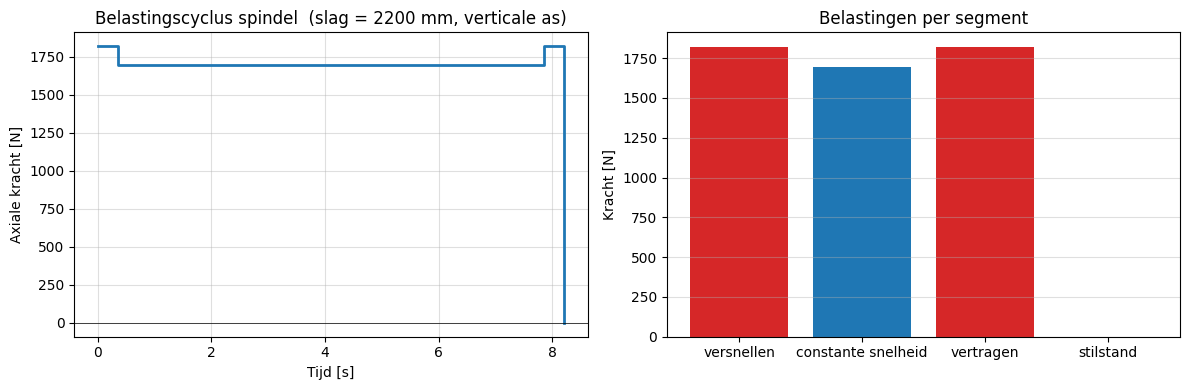

In [17]:
plot_belastingscyclus_spindel(tabel_cyclus_spindel)

EXPORT

In [18]:
resultaten_spindel = {
    "configuratie_beweging":  asdict(cfg_beweging),
    "configuratie_spindel":   asdict(cfg_spindel),
    "cyclus_spindel":         cyclus_spindel.copy(),
    "eisen_spindel":          eisen_spindel.copy(),
    "controle_spindel":       controle_spindel.copy(),
    "pass_fail_spindel":      pass_fail_spindel.copy(),
    "tabel_cyclus_spindel":   tabel_cyclus_spindel.copy(),
    "overzicht_spindel":      overzicht_spindel.copy(),
    "export_voor_volgende_modules": {
        # Beweging
        "n_bedrijf_rpm":              controle_spindel["n_bedrijf_rpm"],
        "v_piek_m_s":                 cyclus_spindel["v_piek_m_s"],
        "t_versnellen_s":             cyclus_spindel["t_versnellen_s"],
        "t_constante_snelheid_s":     cyclus_spindel["t_constante_snelheid_s"],
        "t_vertragen_s":              cyclus_spindel["t_vertragen_s"],
        # Krachten
        "F_piek_N":                   eisen_spindel["F_piek_N"],
        "F_eq_N":                     eisen_spindel["F_eq_N"],
        # Spindel
        "koppel_piek_spindel_Nm":     controle_spindel["koppel_piek_Nm"],
        "vermogen_piek_spindel_kW":   controle_spindel["vermogen_piek_kW"],
        "spoed_spindel_m":            cfg_spindel.spoed_spindel_m,
        "rendement_spindel":          cfg_spindel.rendement_spindel,
        "nominale_diameter_spindel_m": cfg_spindel.nominale_diameter_spindel_m,
        "totale_lengte_spindel_m":    cfg_spindel.totale_lengte_spindel_m,
        "extra_axiale_kracht_N":      cfg_spindel.extra_axiale_kracht_N,
        # Geometrie-metadata
        "m1_slag_m":                  M1_SLAG_M,
        "m1_vrije_lengte_m":          M1_VRIJE_LENGTE_M,
        "m1_schacht_totaal_m":        M1_SCHACHT_TOTAAL_M,
    },
}

print("\n=== EXPORT VOOR VOLGENDE MODULES ===")
print(pd.Series(resultaten_spindel["export_voor_volgende_modules"]).to_string())


=== EXPORT VOOR VOLGENDE MODULES ===
n_bedrijf_rpm                   840.000000
v_piek_m_s                        0.280000
t_versnellen_s                    0.350000
t_constante_snelheid_s            7.507143
t_vertragen_s                     0.350000
F_piek_N                       1821.024949
F_eq_N                         1706.322805
koppel_piek_spindel_Nm            6.300546
vermogen_piek_spindel_kW          0.554225
spoed_spindel_m                   0.020000
rendement_spindel                 0.920000
nominale_diameter_spindel_m       0.040000
totale_lengte_spindel_m           2.478000
extra_axiale_kracht_N          1291.287581
m1_slag_m                         2.200000
m1_vrije_lengte_m                 2.350000
m1_schacht_totaal_m               2.478000
